In [1]:
# Core libraries 
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# Modelling libraries 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
# XGBoost is optional: if it isn't installed, OR if it fails to load for any other
# reason (e.g. a missing libomp/OpenMP runtime on Mac), we fall back to scikit-learn's
# GradientBoostingRegressor so the notebook still runs end-to-end either way.
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print(f"xgboost could not be loaded ({type(e).__name__}) -> falling back to sklearn's GradientBoostingRegressor.")

RANDOM_STATE = 42

xgboost could not be loaded (XGBoostError) -> falling back to sklearn's GradientBoostingRegressor.


In [3]:
# Import data

df = pd.read_csv('DiamondPricePredictionDataSet.csv')
df

,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


### Info about the dataset attributes:

* **Carat:** Weight of the diamond.
* **Cut:** Quality of the cut (Order: Fair, Good, Very Good, Premium, Ideal).
* **Color:** Diamond color (From J = worst to D = best).
* **Clarity:** Measurement of transparency. Sequence from worst to best: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF.
* **Table:** Width of the top of the diamond.
* **Price:** Price in US dollars (This is our Target Variable).
* **X:** Length of the diamond in mm.
* **Y:** Width of the diamond in mm.
* **Z:** Depth of the diamond in mm.
* **Depth:** Total depth percentage. It can be calculated as: `Z * 2 / (X + Y)`.

# 1. Data Quality Check
Lets validate the raw data first: missing values, duplicated rows,
and physically impossible measurements... 

In [4]:
# Structure, data types and missing values
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Carat(Weight of Daimond)  53940 non-null  float64
 1   Cut(Quality)              53940 non-null  str    
 2   Color                     53940 non-null  str    
 3   Clarity                   53940 non-null  str    
 4   Depth                     53940 non-null  float64
 5   Table                     53940 non-null  float64
 6   Price(in US dollars)      53940 non-null  int64  
 7   X(length)                 53940 non-null  float64
 8   Y(width)                  53940 non-null  float64
 9   Z(Depth)                  53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB

Missing values per column:
 Carat(Weight of Daimond)    0
Cut(Quality)                0
Color                       0
Clarity                     0
Depth                       0
Table

**Insight:**
No imputation is needed since there are no missing values. 
We drop duplicate rows to prevent train/test data leakage, as different diamonds can coincidentally share the exact same attributes. Keeping them might artificially inflate evaluation metrics.

In [5]:
# A diamond cannot have zero length/width/depth, so these are data-entry errors, not real observations.
# We remove them here so they don't distort correlations or model training later.
invalid_dimension_mask = (df[[X_COL := 'X(length)', Y_COL := 'Y(width)', Z_COL := 'Z(Depth)']] == 0).any(axis=1)
print(f"Rows with an impossible (zero) dimension: {invalid_dimension_mask.sum()}")

df = df.loc[~invalid_dimension_mask].reset_index(drop=True)
print(f"Dataset shape after cleaning: {df.shape}")
df.describe()

Rows with an impossible (zero) dimension: 20
Dataset shape after cleaning: (53920, 10)


,Carat(Weight of Daimond),Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


**Note:** I have dropped the rows that had zero length or width since it doesn't exist. 

# 2. Exploratory Data Analysis

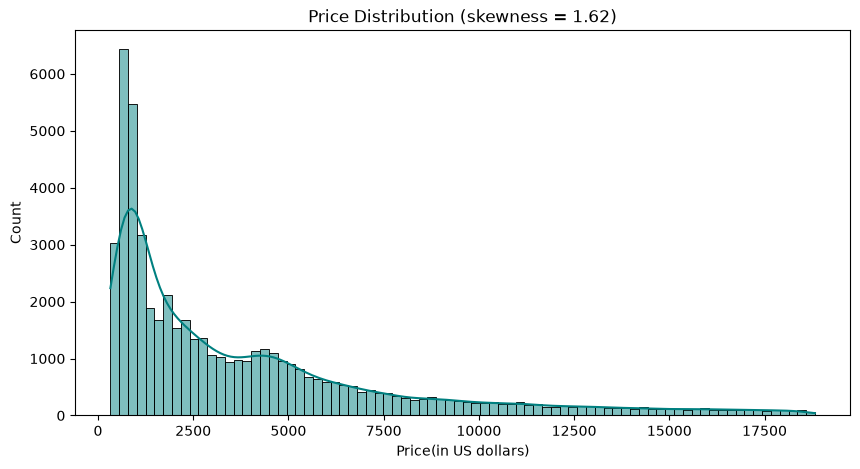

Skewness of Price: 1.62


In [6]:
# Distribution of the target variable (Price) and its skewness.
# This tells us whether a log-transform of the target is worthwhile before modelling .
price_skewness = skew(df['Price(in US dollars)'])

plt.figure(figsize=(10, 5))
sns.histplot(df['Price(in US dollars)'], kde=True, color='teal')
plt.title(f"Price Distribution (skewness = {price_skewness:.2f})")
plt.xlabel('Price(in US dollars)')
plt.show()

print(f"Skewness of Price: {price_skewness:.2f}")

**Insight:** Price is strongly right-skewed (most diamonds are cheap, with a long tail of
expensive ones). A skewness well above 1 means a linear model trained directly on raw dollar
prices will be dominated by a few very expensive diamonds. We will train on `log1p(Price)`
later and convert predictions back to dollars for evaluation.

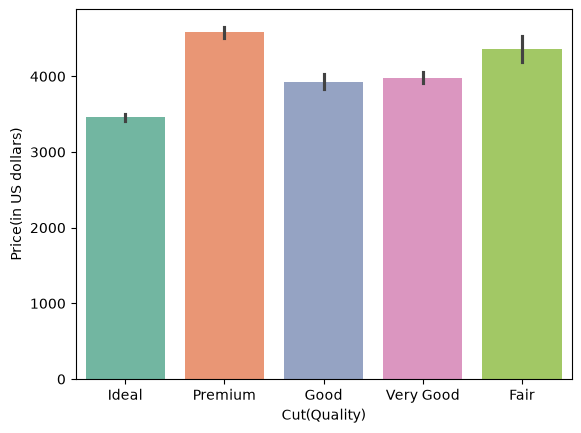

In [7]:
sns.barplot(
    data=df, x="Cut(Quality)", y="Price(in US dollars)", palette="Set2", hue="Cut(Quality)", legend=False)
plt.show()

Premium Quality has the highest price for dimond

<Axes: xlabel='Carat(Weight of Daimond)', ylabel='Price(in US dollars)'>

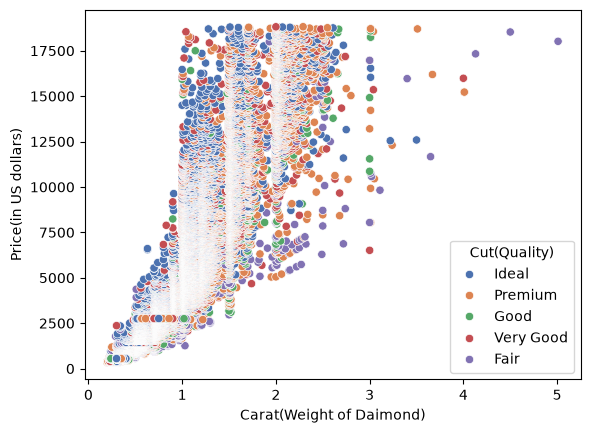

In [8]:
sns.scatterplot(data=df, x="Carat(Weight of Daimond)", y="Price(in US dollars)", hue="Cut(Quality)", palette="deep")

**Insight:** The relationship between carat and price is clearly non-linear.

<Axes: xlabel='Color', ylabel='Price(in US dollars)'>

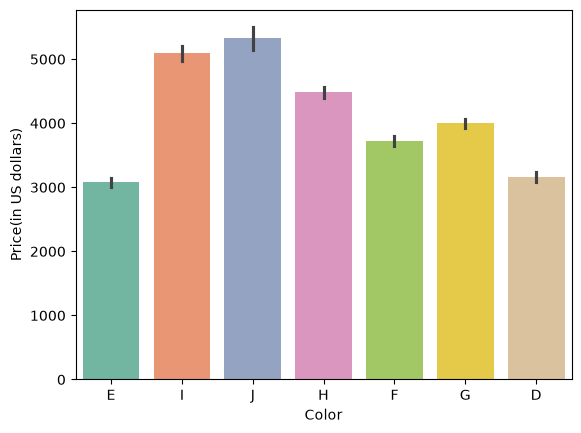

In [9]:
#from J -> 'worst' to D -> 'Best'
sns.barplot(data=df, x="Color", y="Price(in US dollars)",palette="Set2", hue="Color", legend=False)


**Note:** Worse-color stones are often larger, because buyers who want a big showy stone accept lower color to stay in budget. 

<Axes: xlabel='Clarity', ylabel='Price(in US dollars)'>

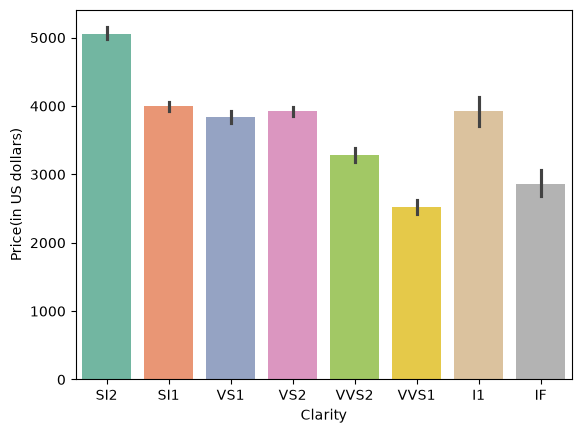

In [10]:
#Clarity -> Measurement of Transparency(how clear the Diamond is) 
#Sequence of clarity ( I1 (worst quality), SI2, SI1, VS2, VS1, VVS2, VVS1, IF(best quality) ).
sns.barplot(data=df, x="Clarity", y="Price(in US dollars)",palette="Set2", hue="Clarity", legend=False)


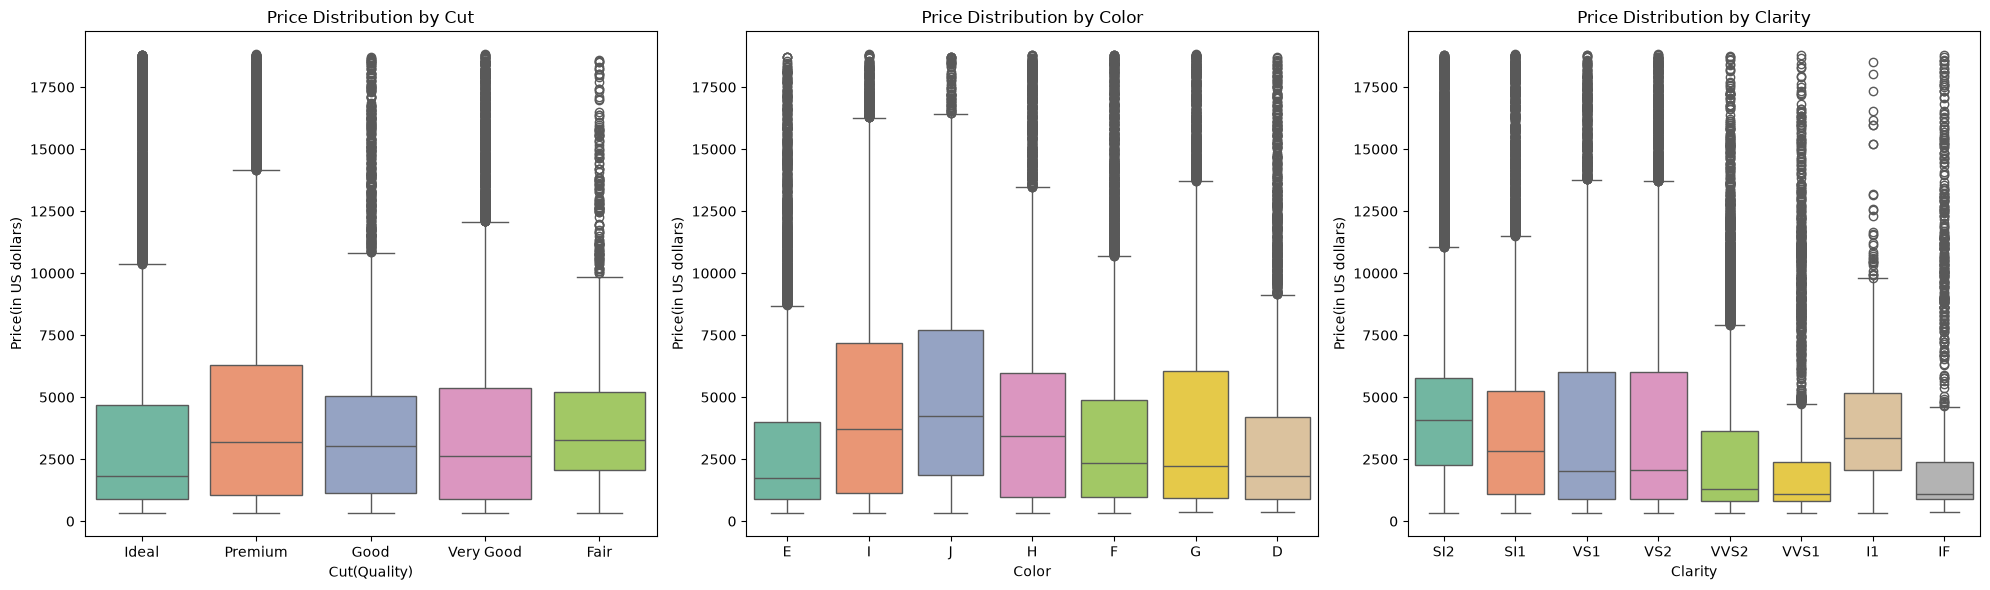

In [11]:
# Boxplots give a fuller picture than bar charts of the mean alone: they show the spread and
# outliers of price within each category
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x="Cut(Quality)", y="Price(in US dollars)", hue="Cut(Quality)", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Price Distribution by Cut")

sns.boxplot(data=df, x="Color", y="Price(in US dollars)", hue="Color", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Price Distribution by Color")

sns.boxplot(data=df, x="Clarity", y="Price(in US dollars)", hue="Clarity", palette="Set2", legend=False, ax=axes[2])
axes[2].set_title("Price Distribution by Clarity")

plt.tight_layout()
plt.show()

**Note:** Box = middle 50% of data, line = median. Median low + long upper whisker/outliers = right-skew.

**Insight:** All three boxplots are right-skewed (low median, long upper whisker, many outliers). Most diamonds are cheap, with a long tail of expensive ones (as we saw before).

In [12]:
df.dtypes

Carat(Weight of Daimond)    float64
Cut(Quality)                    str
Color                           str
Clarity                         str
Depth                       float64
Table                       float64
Price(in US dollars)          int64
X(length)                   float64
Y(width)                    float64
Z(Depth)                    float64
dtype: object

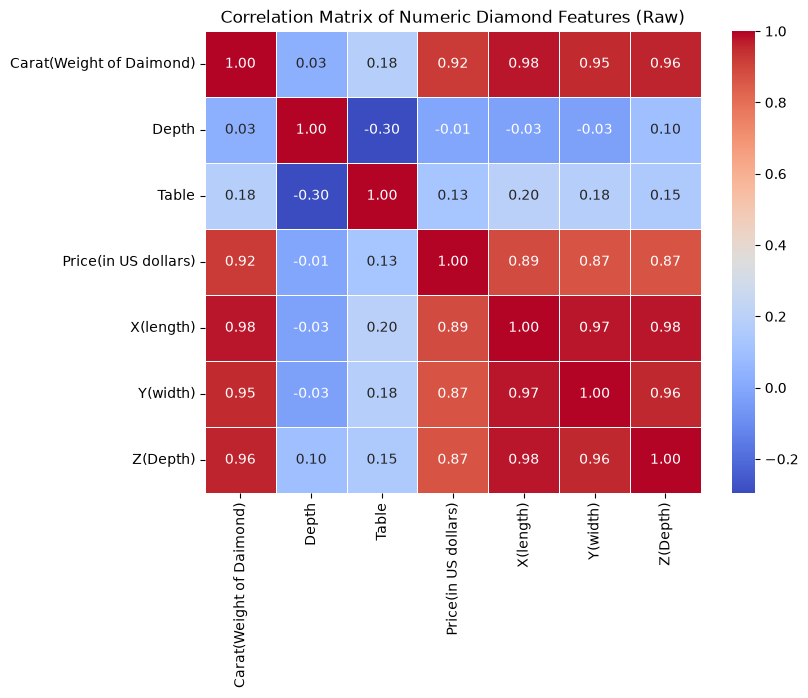

In [13]:
# CORRELATION MATRIX (Only Original Numeric Features, before encoding)
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Numeric Diamond Features (Raw)")
plt.show()

**Insight**: Carat, X, Y, Z are highly correlated with each other (all around 0.95–0.98) and with Price (around 0.87–0.92), which makes physical sense, since carat is essentially a function of the diamond's volume. Depth and Table show almost no linear correlation with price (both near 0), meaning a diamond's proportions matter far less to price than its raw size does. Practical implication: X, Y, Z and Carat carry largely overlapping information (multicollinearity), which hurts the interpretability of Linear Regression coefficients but is not a problem for tree-based models, which split on one feature at a time regardless of correlation with others.

# 3. Feature Engineering & Data Preprocessing

In [14]:
df['Cut(Quality)'].unique()

<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [15]:
# Fair -> Good -> Very Good -> Premium -> Ideal (worst to best)
cut_mapping = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
df['Cut(Quality)'] = df['Cut(Quality)'].map(cut_mapping)
print("Cut(Quality) encoded:", df['Cut(Quality)'].unique())

Cut(Quality) encoded: [4 3 1 2 0]


In [16]:
df['Color'].unique()

<StringArray>
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Length: 7, dtype: str

In [17]:
# real quality order, worst (J) to best (D), matching the dataset documentation above.
color_mapping = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
df['Color'] = df['Color'].map(color_mapping)
print("Color encoded (0=worst J ... 6=best D):", df['Color'].unique())

Color encoded (0=worst J ... 6=best D): [5 1 0 2 4 3 6]


In [18]:
df['Clarity'].unique()

<StringArray>
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Length: 8, dtype: str

In [19]:
clarity_mapping = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}
df['Clarity'] = df['Clarity'].map(clarity_mapping)
print("Clarity encoded (0=worst I1 ... 7=best IF):", df['Clarity'].unique())

Clarity encoded (0=worst I1 ... 7=best IF): [1 2 4 3 5 6 0 7]


**Insight:** Using an explicit ordinal map (instead of `LabelEncoder`) means a model that learns "higher
code -> generally higher price" is learning a real, physically meaningful relationship (better clarity/color
tends to raise price), not an arbitrary artefact of the alphabet. This especially matters for Linear
Regression, whose coefficients directly assume the encoded numbers are meaningfully ordered.

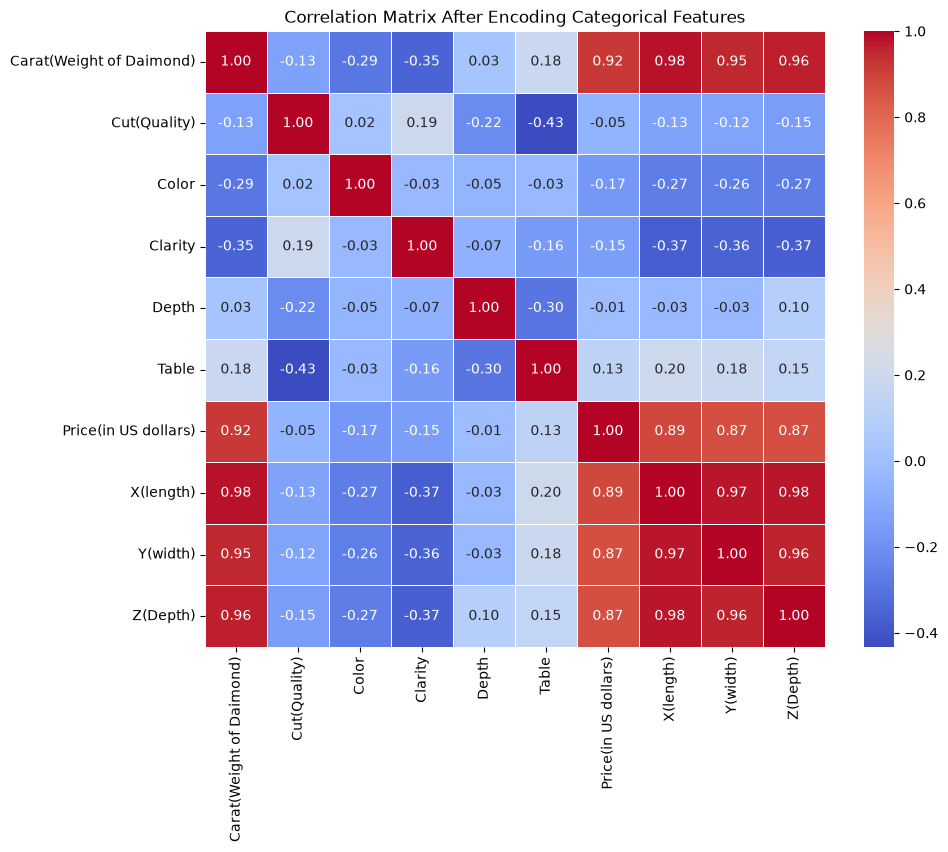

In [20]:
# Correlation matrix after encoding categorical quality grades numerically
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix After Encoding Categorical Features")
plt.show()

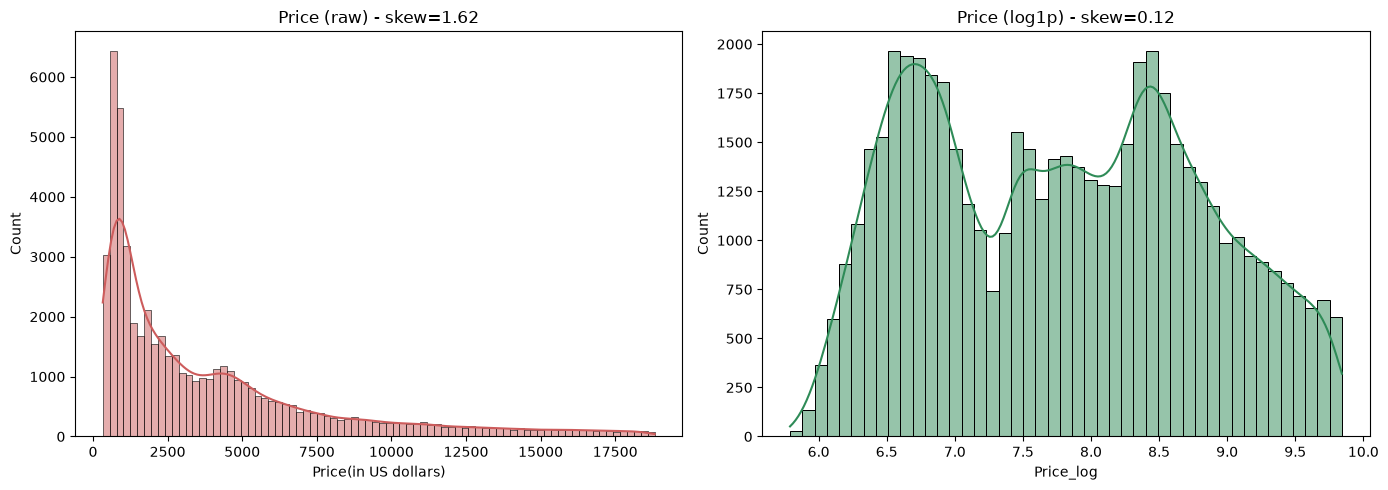

In [21]:
# Log-transform the target to fix the right-skew identified earlier.
# np.log1p (= log(1 + x)) is used instead of plain log so that it stays well-defined even if Price were 0.
df['Price_log'] = np.log1p(df['Price(in US dollars)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Price(in US dollars)'], kde=True, ax=axes[0], color='indianred')
axes[0].set_title(f"Price (raw) - skew={skew(df['Price(in US dollars)']):.2f}")

sns.histplot(df['Price_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"Price (log1p) - skew={skew(df['Price_log']):.2f}")

plt.tight_layout()
plt.show()

**Insight:** `log1p(Price)` is far closer to a symmetric distribution than raw Price (skew drops from ~1.6 to ~0.1). Training on this log-target means that expensive diamonds don't dominate the fit. Predictions are converted back to dollars (`expm1`) inside `evaluate_model()` for consistent, interpretable scoring.

In [22]:
# Wanted to try Advanced engineered features 
# Trees might be able to approximate this themselves
# 1. Carat Squared: captures the non-linear/exponential relationship between carat and price
#    that we saw in the "Carat vs Price" scatterplot (price accelerates, it doesn't just scale linearly).
df['Carat_Squared'] = df['Carat(Weight of Daimond)'] ** 2

# 2. Carat & Depth Interaction: combines weight and proportion.
# Insight: a very deep diamond hides its weight at the bottom, making it look smaller from the top
# and reducing its sparkle, this makes it less valuable despite a high carat weight.
df['Carat_Depth'] = df['Carat(Weight of Daimond)'] * df['Depth']

# 3. Diamond Volume (x * y * z): represents the physical 3D space the stone occupies,
# which correlates with carat but is not mathematically identical to it (carat is a weighted mass,
# volume is a raw geometric size), so it can pick up shape/density nuances carat alone misses.
df['Volume'] = df['X(length)'] * df['Y(width)'] * df['Z(Depth)']

df[['Carat_Squared', 'Carat_Depth', 'Volume']].describe()

,Carat_Squared,Carat_Depth,Volume
count,53920.00000,53920.000000,53920.000000
mean,0.86080,49.276657,129.897567
std,1.05555,29.343722,78.219789
min,0.04000,11.800000,31.707984
25%,0.16000,24.520000,65.189759
50%,0.49000,43.594000,114.840180
75%,1.08160,64.872000,170.846415
max,25.10010,328.155000,3840.598060


# 4. ML Model Buiding 

In [23]:
# We drop BOTH price columns for a reason:
#   - 'Price(in US dollars)' is the raw target -> if left in X, the model would
#     just "read" the answer from a feature instead of learning from carat/cut/etc.
#   - 'Price_log' is the log-transformed version of that SAME answer -> same problem,
#     just disguised. Leaving either one in X is called "data leakage": your metrics
#     would look almost perfect, but the model would be useless on real new data.

X = df.drop(columns=['Price(in US dollars)', 'Price_log'])
y = df['Price_log']

print("Feature columns used for modelling:")
print(list(X.columns))

Feature columns used for modelling:
['Carat(Weight of Daimond)', 'Cut(Quality)', 'Color', 'Clarity', 'Depth', 'Table', 'X(length)', 'Y(width)', 'Z(Depth)', 'Carat_Squared', 'Carat_Depth', 'Volume']


In [24]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 43136 | Test size: 10784


In [25]:
# Reusable evaluation helper: avoids copy-pasting the same MAE/MSE/RMSE/R2 block for every model,
# and makes sure every model is judged on the SAME real-dollar scale by inverse-transforming
# the log predictions with expm1 before scoring.
def evaluate_model(model_name, y_true_log, y_pred_log, store=True):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    r2 = metrics.r2_score(y_true, y_pred)

    print(f"-{model_name} Performance (USD scale):-")
    print(f"MAE: ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2: {r2:.4f}\n")

    if store:
        model_results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return y_pred

model_results = []

**Insight:** Converting back to dollars with `expm1` before computing MAE/RMSE is essential. If we scored on the log scale directly, "2,000 dollar error on a 500,000 dollar diamond" and "2,000 dollar error on a 500 dollar diamond" would look identical in log-space but mean very different things in practice. Reporting in dollars keeps the metrics interpretable for a non-technical stakeholder (e.g. "on average we're off by about $X").

## Linear Regression

In [26]:
linear_model = Pipeline([
    ('scaler', StandardScaler()),  # normalizes the features 
    ('regressor', LinearRegression()) # model
])

linear_model.fit(X_train, y_train_log)

y_pred_linear_log = linear_model.predict(X_test)
_ = evaluate_model('Linear Regression (Baseline)', y_test_log, y_pred_linear_log)

-Linear Regression (Baseline) Performance (USD scale):-
MAE: $2,075.12
RMSE: $165,787.87
R2: -1713.4274



**Insight:** As the simplest possible baseline, Linear Regression's job is only to give us a floor to beat.
Because it can only draw a straight (hyper)plane through the data, it can't bend to follow the accelerating
carat-price curve we saw in the scatterplot, so we expect it to underperform every tree-based model below.

## Decision Tree Regressor

(Design Model, Train, Predict, Evaluate)

In [27]:
dtree = DecisionTreeRegressor(random_state=RANDOM_STATE)
dtree.fit(X_train, y_train_log)

y_pred_dtree_log = dtree.predict(X_test)
_ = evaluate_model('Decision Tree', y_test_log, y_pred_dtree_log)

-Decision Tree Performance (USD scale):-
MAE: $349.78
RMSE: $719.60
R2: 0.9677



**Insight:** A single Decision Tree should beat Linear Regression easily (see R2).
Its weakness: it tends to overfit, memorizing noise instead of the general pattern, which is exactly what Random Forest fixes next by averaging many trees.

## Random Forest Regressor

In [28]:
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train_log)

y_pred_rf_log = rf.predict(X_test)
_ = evaluate_model('Random Forest', y_test_log, y_pred_rf_log)

-Random Forest Performance (USD scale):-
MAE: $259.96
RMSE: $533.70
R2: 0.9822



**Insight:** Random Forest trains many Decision Trees on random subsets of rows and features, then averages their predictions. Averaging cancels out each individual tree's overfit quirks while keeping their shared ability to model non-linear relationships, so it typically lands between "a single deep tree" (overfits) and"Linear Regression" (underfits) in terms of stability (usually with noticeably better test-set accuracy than both).

## Gradient Boosting / XGBoost Regressor


In [29]:
if XGBOOST_AVAILABLE:
    gb_model = XGBRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    gb_model_name = 'XGBoost'
else:
    gb_model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=3,
        random_state=RANDOM_STATE
    )
    gb_model_name = 'Gradient Boosting'

gb_model.fit(X_train, y_train_log)

y_pred_gb_log = gb_model.predict(X_test)
_ = evaluate_model(gb_model_name, y_test_log, y_pred_gb_log)

-Gradient Boosting Performance (USD scale):-
MAE: $282.20
RMSE: $547.11
R2: 0.9813



**Insight:** Unlike Random Forest (which builds trees independently and averages them), boosting builds
trees *sequentially*, where each new tree specifically targets the errors the previous trees made. This
usually squeezes out extra accuracy versus Random Forest, at the cost of being more sensitive to
hyperparameters (learning rate, depth, number of trees) — which is exactly what we tune next.

**Note:** `n_estimators=300`, `learning_rate=0.1`, `max_depth=6` (XGBoost) / `3` (Gradient Boosting) are common starting-point defaults, not values tuned for this dataset. `n_estimators` = how many trees; `learning_rate` = how much each new tree corrects previous errors (lower = safer but needs more trees); `max_depth` = how deep each tree can grow (deeper = more complex but risks overfitting). Section 5 tunes these properly via `GridSearchCV`.


# 5. Hyperparameter tuning 

Hyperparameter tuning is the process of systematically testing different model settings
(e.g. `n_estimators`, `max_depth`, `learning_rate`) to find the combination that generalizes best,
instead of guessing default values. `GridSearchCV` does this exhaustively: it tries every combination
in the given grid, using k-fold cross-validation (splitting the training data into folds and rotating
which fold is held out) so the chosen combination isn't just lucky on one particular split. The grids
below are kept small on purpose, to keep runtime reasonable while still testing a few realistic values
for each hyperparameter.

In [30]:
rf_param_grid = {
    'n_estimators': [200, 400],      
    'max_depth': [10, 20, None],      
    'min_samples_split': [2, 5],       
    'min_samples_leaf': [1, 2],       
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train_log)

print("Best Random Forest params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

y_pred_rf_tuned_log = best_rf.predict(X_test)
_ = evaluate_model('Random Forest (Tuned)', y_test_log, y_pred_rf_tuned_log)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
-Random Forest (Tuned) Performance (USD scale):-
MAE: $259.32
RMSE: $530.36
R2: 0.9825



In [31]:
if XGBOOST_AVAILABLE:
    gb_param_grid = {
        'n_estimators': [200, 400],        # was [200, 300, 400, 500]
        'max_depth': [4, 6, 8],            # was [3, 4, 5, 6, 8]
        'learning_rate': [0.05, 0.1],      # was [0.01, 0.05, 0.1, 0.2]
        'subsample': [0.8, 1.0],           # was [0.7, 0.8, 1.0]
    }
    gb_estimator = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
else:
    gb_param_grid = {
        'n_estimators': [200, 400],        # was [200, 300, 400]
        'max_depth': [3, 5],               # was [2, 3, 4, 5]
        'learning_rate': [0.05, 0.1],      # was [0.01, 0.05, 0.1, 0.2]
        'min_samples_split': [2, 5],       # was [2, 5, 10]
    }
    gb_estimator = GradientBoostingRegressor(random_state=RANDOM_STATE)

gb_search = GridSearchCV(
    estimator=gb_estimator,
    param_grid=gb_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
gb_search.fit(X_train, y_train_log)

print(f"Best {gb_model_name} params:", gb_search.best_params_)
best_gb = gb_search.best_estimator_

y_pred_gb_tuned_log = best_gb.predict(X_test)
_ = evaluate_model(f'{gb_model_name} (Tuned)', y_test_log, y_pred_gb_tuned_log)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 400}
-Gradient Boosting (Tuned) Performance (USD scale):-
MAE: $262.37
RMSE: $516.98
R2: 0.9833



**Note: about grid values were picked.**
Based on common "sensible ranges" for tree-based models.
  
- `n_estimators`: 200-400 (rarely helps much beyond that)
- `max_depth`: moderate (too deep overfits, too shallow underfits)
- `learning_rate`: 0.05-0.1 (standard safe range for boosting)
- Trimmed to 2-3 values per hyperparameter to keep runtime reasonable — fewer values = far fewer total combinations for `GridSearchCV` to test

**Remember about MAE vs RMSE.** Both measure prediction error in dollars, but differently: 

- MAE is the average error size, treating every mistake equally. 

- RMSE squares errors before averaging (then square-roots back), so it punishes large mistakes much more heavily.

If MAE and RMSE are close, errors are consistent. If RMSE is much higher, a few large misses are
dragging it up.

# 6. Final Model Comparison

In [32]:
results_df = pd.DataFrame(model_results).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting (Tuned),262.367925,516.978529,0.983329
1,Random Forest (Tuned),259.321410,530.362176,0.982455
2,Random Forest,259.964287,533.703214,0.982233
3,Gradient Boosting,282.198719,547.107169,0.981329
4,Decision Tree,349.780801,719.597682,0.967701
5,Linear Regression (Baseline),2075.117969,165787.865320,-1713.427428


**Note:** RMSE punishes large errors more than small ones, as we mentioned before. So ranking by RMSE picks the model that avoids
big, costly mistakes, not just the lowest average error. That fits a pricing tool, where badly mispricing
an expensive diamond matters more than small misses on cheap ones.

# 7. Predictions & Insights

In [37]:
# Identify the best model automatically from the comparison table above,

best_model_name = results_df.iloc[0]['Model']
print(f"Best performing model: {best_model_name}")

candidate_models = {
    'Linear Regression (Baseline)': linear_model,
    'Decision Tree': dtree,
    'Random Forest': rf,
    gb_model_name: gb_model,
    'Random Forest (Tuned)': best_rf,
    f'{gb_model_name} (Tuned)': best_gb,
}
best_model = candidate_models[best_model_name]

Best performing model: Gradient Boosting (Tuned)


## Feature importance

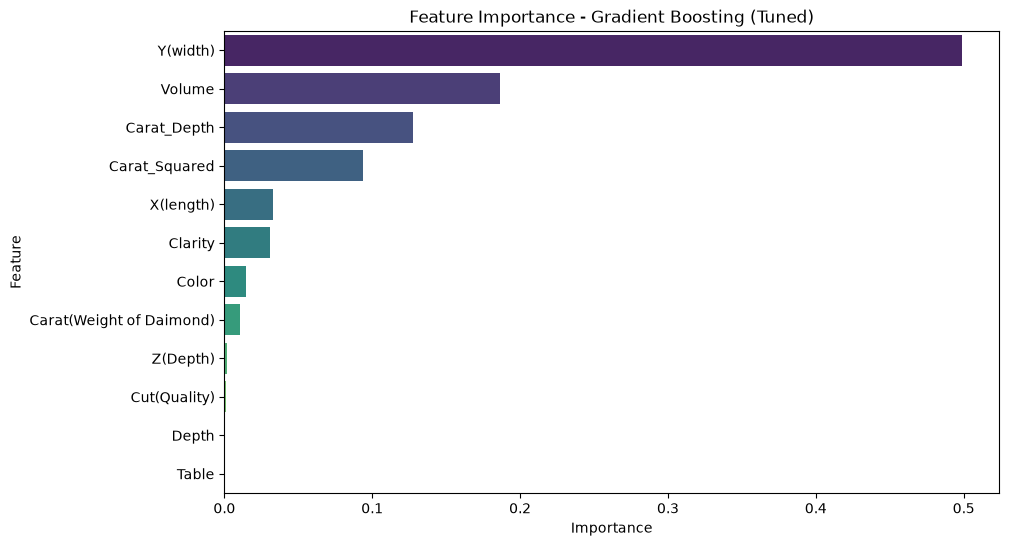

In [35]:
# Feature importance (only meaningful for tree-based models; Linear Regression uses coefficients instead).

if hasattr(best_model, 'feature_importances_'): #hasattr: ¿el modelo que ganó (best_model) tiene la propiedad feature_importances_?
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()
else: # si por alguna razón el ganador fuera Linear Regression, usa .coef_ en su lugar hasattr
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': best_model.named_steps['regressor'].coef_
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f"Standardized Coefficients - {best_model_name}")
    plt.show()

**Insight:** Carat (and the engineered Volume / Carat_Squared features derived from it) dominates feature importance. Clarity, Color and Cut contribute meaningfully but far less than size-related features.

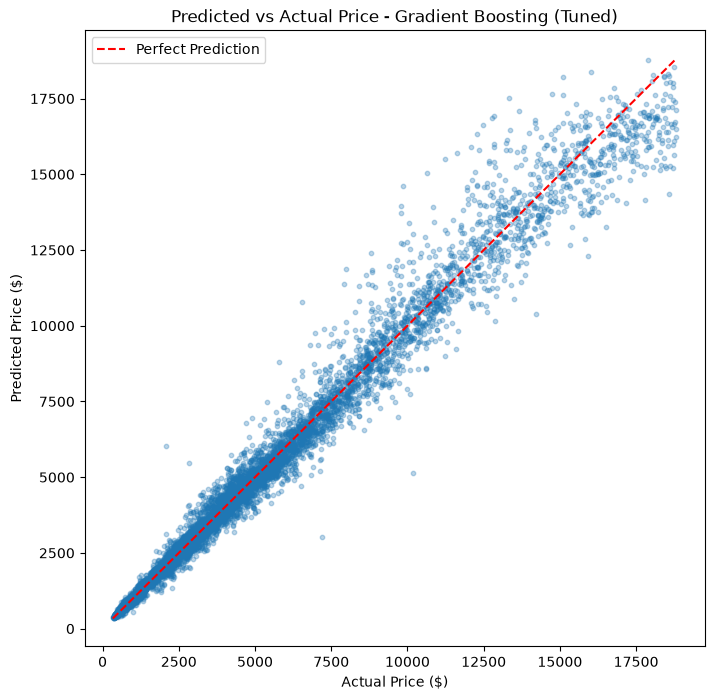

In [36]:
# Predicted vs Actual price for the best model (dollar scale).
y_pred_best_log = best_model.predict(X_test) # blue dots -> best model
y_pred_best = np.expm1(y_pred_best_log)
y_test_actual = np.expm1(y_test_log)

plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_pred_best, alpha=0.3, s=10)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color='red', linestyle='--', label='Perfect Prediction'
)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Predicted vs Actual Price - {best_model_name}')
plt.legend()
plt.show()

# 8. Conclusion and Future Improvements  

**Conclusion:** The tuned Gradient Boosting Regressor was the best-performing model (MAE ≈ 262 USD, RMSE ≈ 517 USD, R² ≈ 0.983), narrowly ahead of the tuned Random Forest. All tree-based models heavily outperformed the Linear Regression baseline (RMSE in the hundreds of thousands vs. &#36;500-720), confirmingg that price depends on carat and the engineered size features in a non-linear way that a straight-line model can't capture. Feature importance confirms carat (and the engineered Volume/Carat_Squared features derived from it) is by far the dominant price driver, while clarity, color and cut add real but secondary value.

**Future Improvements:**
- Incorporate external market factors, such as regional pricing shifts or dealer premiums, to enrich the
  feature space and capture broader economic trends.
- Build an interactive web application to deploy the trained model, allowing users to calculate real-time
  diamond valuations effortlessly.
- Experiment with advanced model stacking and blending techniques to drive prediction errors even lower.
- Integrate explainability tools like SHAP values to provide transparent and intuitive breakdowns for
  individual price estimates.
- Implement ongoing tracking practices to monitor model reliability and performance as real-world market
  dynamics shift over time.
- Add a carat-controlled price analysis (grouping diamonds into similar-size buckets and comparing
  price-per-carat within each group) to properly validate and quantify the quality premium suggested by feature importance.